Running 100 county-wise 70/30 splits: 100%|██████████| 100/100 [01:17<00:00,  1.29it/s]


Cook's distance threshold used: 0.010753
Final selected alpha (full sample): 4.000000
Full-sample R²: 0.7129
Full-sample RMSE: 440.0581

Repeated county-wise 70/30 split results (100 iterations):
Average Train R²: 0.7106
Average Test R²: 0.5354
Average Train RMSE: 440.0171
Average Test RMSE: 543.6600


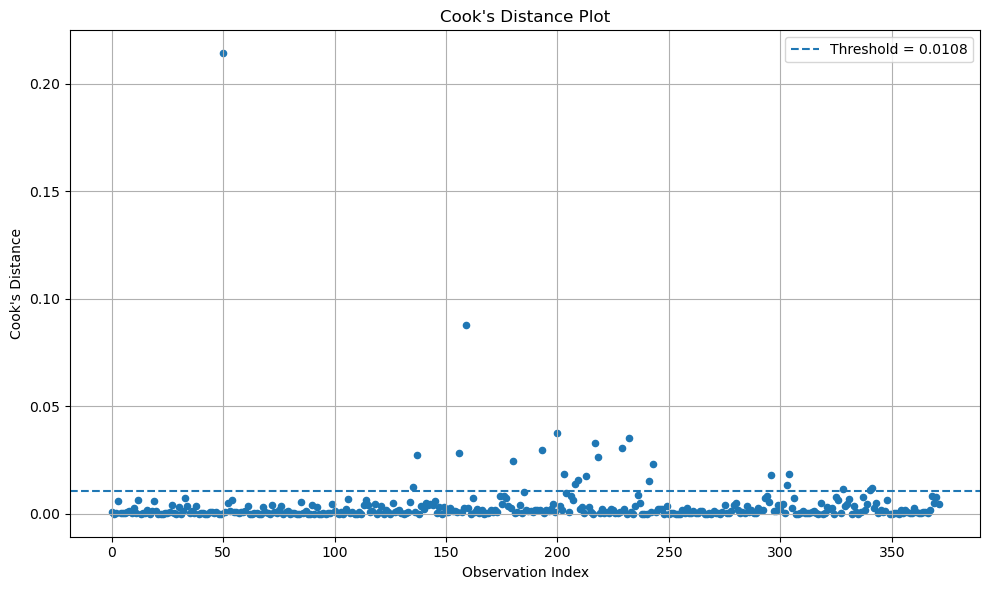

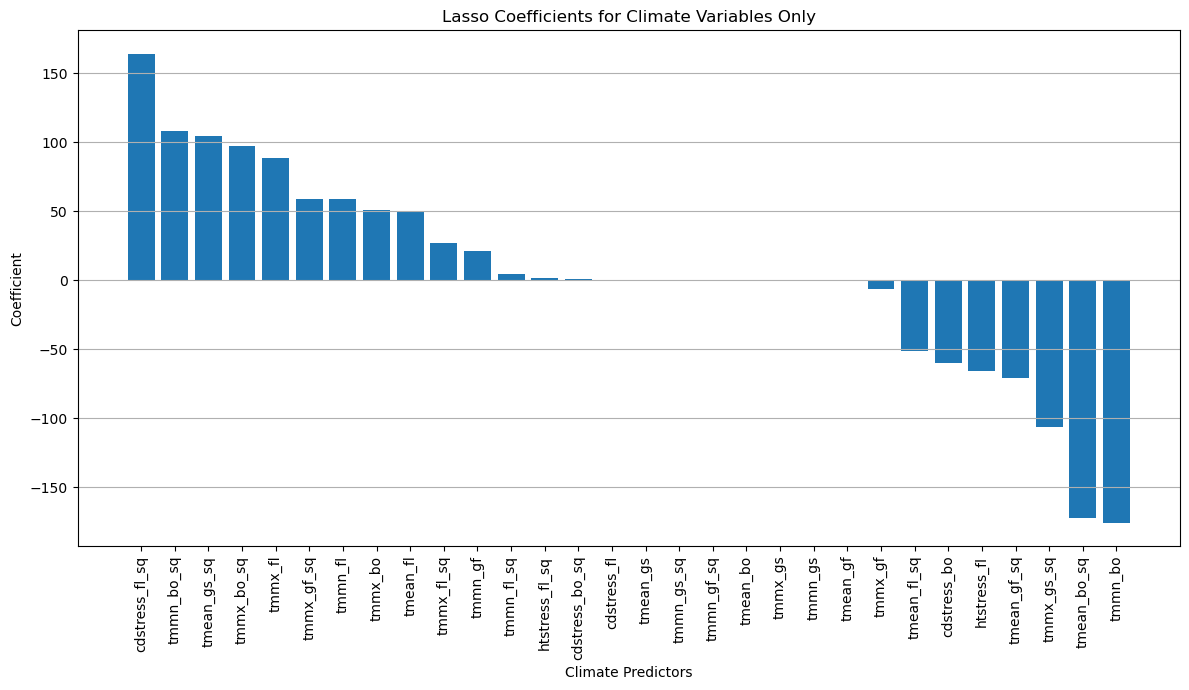

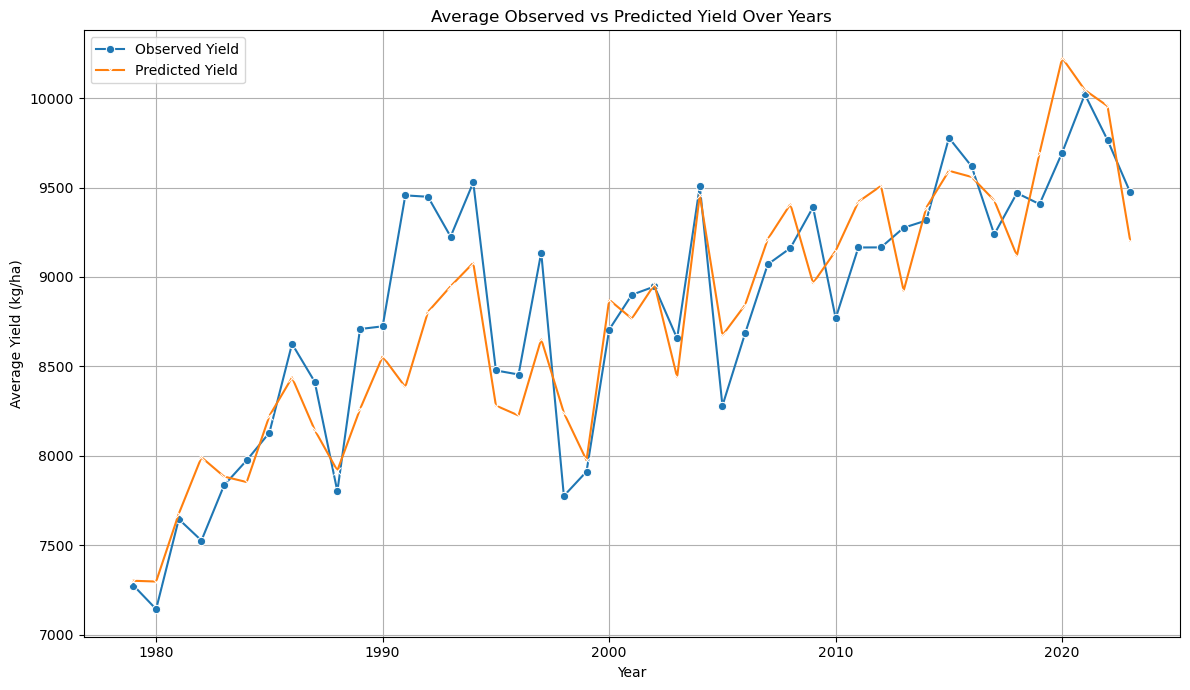

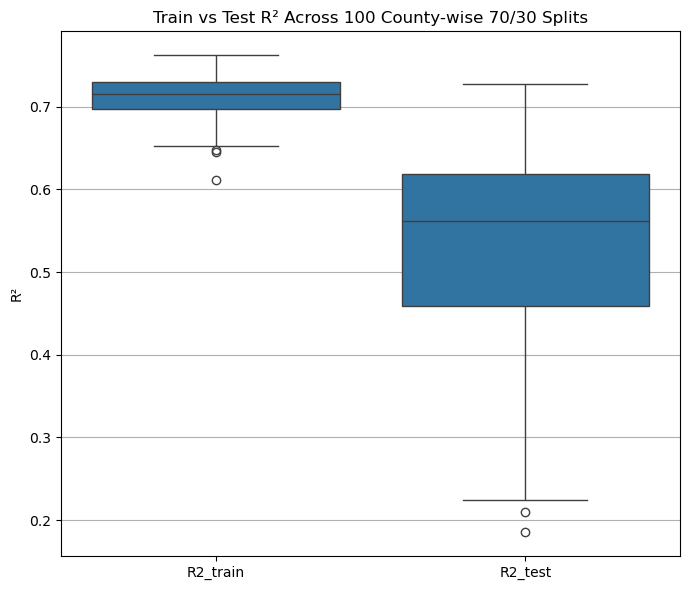

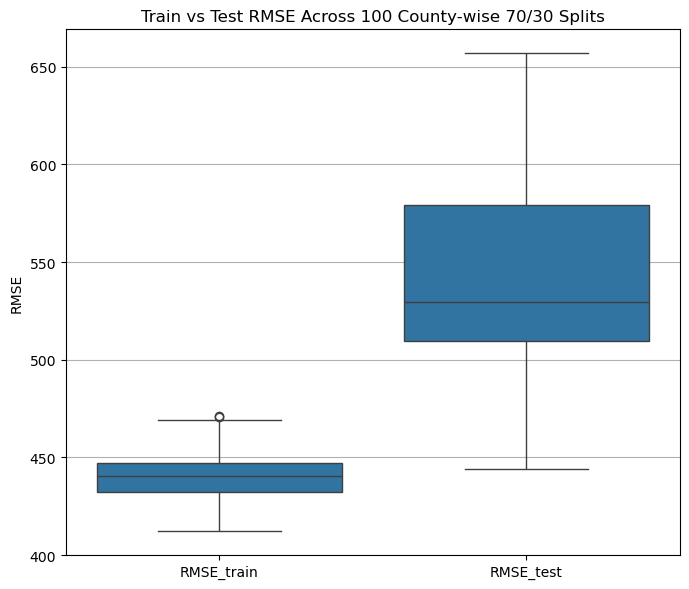

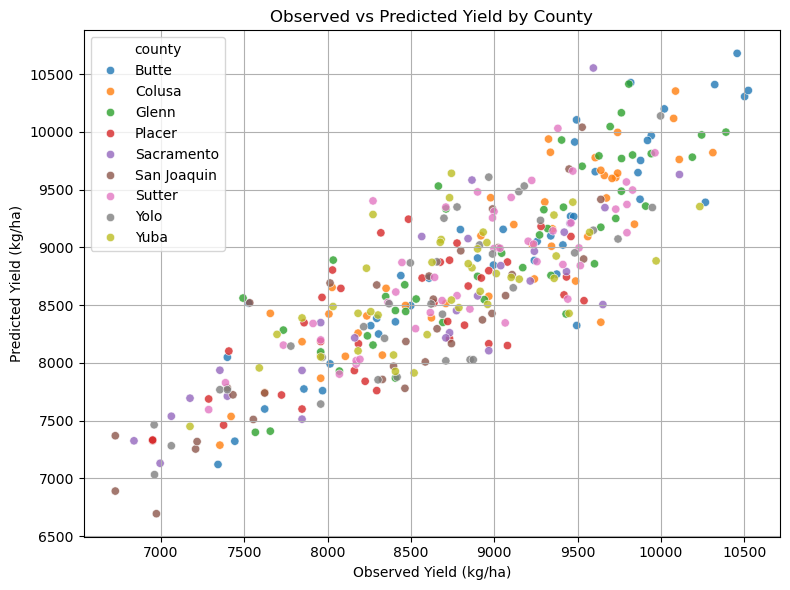

In [2]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LassoCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import statsmodels.api as sm
import joblib
from tqdm import tqdm

# =========================================================
# File paths
# =========================================================

CLIMATE_DIR = "/group/moniergrp/dbaral"
file_path = os.path.join(CLIMATE_DIR, "run_project/input_data/gridmet_hist_model_input")
save_path = os.path.join(CLIMATE_DIR, "run_project/output_data/historical_model")

os.makedirs(save_path, exist_ok=True)


# =========================================================
# Helper function 1
# Load raw data
# =========================================================

def load_raw_data():
    """
    Load the historical gridMET model input dataset.
    """
    df = pd.read_csv(os.path.join(file_path, "Lasso_Model_Input_Variables_1979_2023_v2.csv"))
    return df


# =========================================================
# Helper function 2
# Build design matrix
# =========================================================

def build_design_matrix(df):
    """
    Build design matrix for no-intercept Lasso model.

    Model structure:
        Yield =
            county fixed effects
          + county-specific time trends
          + centered climate variables
          + squared centered climate variables

    Important:
        - no separate intercept
        - all county dummies included
        - county coefficients act as county fixed effects
        - trend starts at 0
        - only climate variables are centered
    """

    df_model = df.copy()

    # -----------------------------------------------------
    # Step 1: remove rows with missing yield
    # -----------------------------------------------------
    df_model = df_model[df_model["yield_kg_ha"].notna()].copy()

    # -----------------------------------------------------
    # Step 2: define climate predictors
    # -----------------------------------------------------
    cols_exclude = ["county", "year", "yield_kg_ha"]
    climate_cols = [c for c in df_model.columns if c not in cols_exclude]

    # -----------------------------------------------------
    # Step 3: center only climate variables
    # -----------------------------------------------------
    climate_center_means = {}

    for col in climate_cols:
        mean_val = df_model[col].mean()
        climate_center_means[col] = float(mean_val)
        df_model[col] = df_model[col] - mean_val

    # -----------------------------------------------------
    # Step 4: create squared terms from centered climate variables
    # -----------------------------------------------------
    for col in climate_cols:
        df_model[f"{col}_sq"] = df_model[col] ** 2

    squared_cols = [f"{c}_sq" for c in climate_cols]

    # -----------------------------------------------------
    # Step 5: create all county dummy variables
    # -----------------------------------------------------
    county_dummies = pd.get_dummies(
        df_model["county"],
        prefix="county",
        drop_first=False
    ).astype(int)

    # -----------------------------------------------------
    # Step 6: create county-specific time trends
    # trend starts at 0 so county coefficient stays baseline FE
    # -----------------------------------------------------
    base_year = int(df_model["year"].min())
    time_trend = df_model["year"] - base_year

    county_trends = county_dummies.multiply(time_trend, axis=0)
    county_trends.columns = [c.replace("county", "trend") for c in county_trends.columns]

    # -----------------------------------------------------
    # Step 7: combine into final design matrix
    # -----------------------------------------------------
    X_df = pd.concat(
        [
            df_model[climate_cols + squared_cols],
            county_dummies,
            county_trends
        ],
        axis=1
    )

    # -----------------------------------------------------
    # Step 8: define response
    # -----------------------------------------------------
    Y = df_model["yield_kg_ha"].copy()

    # -----------------------------------------------------
    # Step 9: save feature order
    # -----------------------------------------------------
    feature_cols_final = list(X_df.columns)

    return (
        df_model,
        X_df,
        Y,
        feature_cols_final,
        climate_cols,
        squared_cols,
        climate_center_means,
        base_year
    )


# =========================================================
# Helper function 3
# Cook's distance diagnostics and outlier removal
# =========================================================

def remove_outliers_with_cooks_distance(df_model, X_df, Y):
    """
    Compute Cook's distance and remove influential points.
    """

    # -----------------------------------------------------
    # Step 1: fit OLS only for influence diagnostics
    # -----------------------------------------------------
    X_const = sm.add_constant(X_df)
    model_sm = sm.OLS(Y, X_const).fit()

    # -----------------------------------------------------
    # Step 2: compute Cook's distance
    # -----------------------------------------------------
    influence = model_sm.get_influence()
    cooks_d = influence.cooks_distance[0]

    # -----------------------------------------------------
    # Step 3: define threshold
    # -----------------------------------------------------
    threshold = 4 / len(Y)

    # -----------------------------------------------------
    # Step 4: apply mask
    # -----------------------------------------------------
    mask = cooks_d < threshold

    df_filtered = df_model.loc[mask].copy()
    X_filtered = X_df.loc[mask].copy()
    Y_filtered = Y.loc[mask].copy()

    return df_filtered, X_filtered, Y_filtered, cooks_d, threshold, mask


# =========================================================
# Helper function 4
# Fit final full-sample no-intercept Lasso model
# =========================================================

def fit_and_save_full_sample_lasso_no_intercept(
    X,
    Y,
    feature_cols_final,
    climate_cols,
    climate_center_means,
    base_year,
    save_path
):
    """
    Fit one final Lasso model with no separate intercept.
    """

    # -----------------------------------------------------
    # Step 1: define alpha grid
    # -----------------------------------------------------
    alphas = [5, 4, 3, 2, 1, 0.5, 0.1, 0.05, 0.01, 0.005, 0.001]

    # -----------------------------------------------------
    # Step 2: build model
    # -----------------------------------------------------
    pipe = Pipeline([
        ("lasso", LassoCV(
            alphas=alphas,
            cv=5,
            max_iter=int(1e7),
            random_state=45,
            fit_intercept=False
        ))
    ])

    # -----------------------------------------------------
    # Step 3: fit model
    # -----------------------------------------------------
    pipe.fit(X, Y)

    # -----------------------------------------------------
    # Step 4: extract fitted lasso
    # -----------------------------------------------------
    lasso = pipe.named_steps["lasso"]

    # -----------------------------------------------------
    # Step 5: save coefficients
    # -----------------------------------------------------
    coef_df = pd.DataFrame({
        "feature": feature_cols_final,
        "coefficient": lasso.coef_
    })

    coef_df.to_csv(
        os.path.join(save_path, "gridmet_hist_coefficients_no_intercept.csv"),
        index=False
    )

    # -----------------------------------------------------
    # Step 6: save pipeline
    # -----------------------------------------------------
    joblib.dump(
        pipe,
        os.path.join(save_path, "gridmet_hist_lasso_pipeline_no_intercept.joblib")
    )

    # -----------------------------------------------------
    # Step 7: save metadata
    # -----------------------------------------------------
    metadata = {
        "alpha_selected": float(lasso.alpha_),
        "r2_full_sample": float(pipe.score(X, Y)),
        "fit_intercept": False,
        "n_samples": int(len(Y)),
        "n_features": int(len(feature_cols_final)),
        "base_year_for_trend": int(base_year),
        "climate_columns": climate_cols,
        "feature_columns_final": feature_cols_final,
        "climate_center_means": climate_center_means
    }

    with open(os.path.join(save_path, "gridmet_hist_model_metadata_no_intercept.json"), "w") as f:
        json.dump(metadata, f, indent=2)

    return pipe, coef_df, metadata


# =========================================================
# Helper function 5
# Run 100 repeated county-wise 70/30 splits
# =========================================================

def run_100_split_validation(X, Y, df_filtered, feature_cols_final, n_iterations=100):
    """
    Run repeated county-wise 70/30 train/test validation.

    Why:
        Instead of trusting one split, we repeat the split 100 times
        to assess:
            - train R2 stability
            - test R2 stability
            - train RMSE stability
            - test RMSE stability

    Returns:
        metrics_df = one row per iteration with train/test metrics
    """

    # -----------------------------------------------------
    # Step 1: define alpha grid
    # -----------------------------------------------------
    alphas = [5, 4, 3, 2, 1, 0.5, 0.1, 0.05, 0.01, 0.005, 0.001]

    # -----------------------------------------------------
    # Step 2: initialize metrics storage
    # -----------------------------------------------------
    metrics_list = []

    # -----------------------------------------------------
    # Step 3: get counties
    # -----------------------------------------------------
    unique_counties = sorted(df_filtered["county"].unique())

    # -----------------------------------------------------
    # Step 4: repeated validation loop
    # -----------------------------------------------------
    for i in tqdm(range(1, n_iterations + 1), desc="Running 100 county-wise 70/30 splits"):

        train_indices = []
        test_indices = []

        # -------------------------------------------------
        # Step 4a: split within each county
        # -------------------------------------------------
        for county in unique_counties:
            county_indices = df_filtered.index[df_filtered["county"] == county]

            train_idx_c, test_idx_c = train_test_split(
                county_indices,
                test_size=0.3,
                random_state=i
            )

            train_indices.extend(train_idx_c)
            test_indices.extend(test_idx_c)

        # -------------------------------------------------
        # Step 4b: build train/test sets
        # -------------------------------------------------
        X_train = X.loc[train_indices]
        X_test = X.loc[test_indices]
        y_train = Y.loc[train_indices]
        y_test = Y.loc[test_indices]

        # -------------------------------------------------
        # Step 4c: fit model
        # -------------------------------------------------
        pipe = Pipeline([
            ("lasso", LassoCV(
                alphas=alphas,
                cv=5,
                max_iter=int(1e7),
                random_state=45,
                fit_intercept=False
            ))
        ])

        pipe.fit(X_train, y_train)

        # -------------------------------------------------
        # Step 4d: predictions
        # -------------------------------------------------
        y_train_pred = pipe.predict(X_train)
        y_test_pred = pipe.predict(X_test)

        # -------------------------------------------------
        # Step 4e: metrics
        # -------------------------------------------------
        r2_train = pipe.score(X_train, y_train)
        r2_test = pipe.score(X_test, y_test)

        rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
        rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

        metrics_list.append({
            "iteration": i,
            "R2_train": r2_train,
            "R2_test": r2_test,
            "RMSE_train": rmse_train,
            "RMSE_test": rmse_test,
            "alpha_selected": pipe.named_steps["lasso"].alpha_
        })

    metrics_df = pd.DataFrame(metrics_list)
    return metrics_df


# =========================================================
# Plot 1
# Cook's distance plot
# =========================================================

def plot_cooks_distance(cooks_d, threshold):
    plt.figure(figsize=(10, 6))
    plt.scatter(np.arange(len(cooks_d)), cooks_d, s=20)
    plt.axhline(threshold, linestyle="--", label=f"Threshold = {threshold:.4f}")
    plt.title("Cook's Distance Plot")
    plt.xlabel("Observation Index")
    plt.ylabel("Cook's Distance")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# =========================================================
# Plot 2
# Coefficients for climate variables only
# =========================================================

def plot_climate_coefficients(coef_df, climate_cols, squared_cols):
    """
    Plot coefficients only for climate-related predictors.
    """

    climate_feature_set = set(climate_cols + squared_cols)
    climate_coef_df = coef_df[coef_df["feature"].isin(climate_feature_set)].copy()
    climate_coef_df = climate_coef_df.sort_values("coefficient", ascending=False)

    plt.figure(figsize=(12, 7))
    plt.bar(climate_coef_df["feature"], climate_coef_df["coefficient"])
    plt.title("Lasso Coefficients for Climate Variables Only")
    plt.xlabel("Climate Predictors")
    plt.ylabel("Coefficient")
    plt.xticks(rotation=90)
    plt.grid(axis="y")
    plt.tight_layout()
    plt.show()


# =========================================================
# Plot 3
# Observed vs predicted yield over years
# =========================================================

def plot_observed_vs_average_predicted(df_filtered, y_pred_full):
    """
    Compare yearly average observed yield vs yearly average predicted yield.
    """

    plot_df = df_filtered.copy()
    plot_df["predicted_yield"] = y_pred_full

    yearly_avg = plot_df.groupby("year")[["yield_kg_ha", "predicted_yield"]].mean().reset_index()

    plt.figure(figsize=(12, 7))
    sns.lineplot(data=yearly_avg, x="year", y="yield_kg_ha", marker="o", label="Observed Yield")
    sns.lineplot(data=yearly_avg, x="year", y="predicted_yield", marker="x", label="Predicted Yield")
    plt.title("Average Observed vs Predicted Yield Over Years")
    plt.xlabel("Year")
    plt.ylabel("Average Yield (kg/ha)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# =========================================================
# Plot 4
# Box plots for repeated 70/30 validation
# =========================================================

def plot_validation_boxplots(metrics_df):
    """
    Make box plots for repeated train/test R2 and RMSE.
    """

    # -----------------------------------------------------
    # Step 1: reshape R2 for box plot
    # -----------------------------------------------------
    r2_long = metrics_df.melt(
        id_vars="iteration",
        value_vars=["R2_train", "R2_test"],
        var_name="metric_type",
        value_name="value"
    )

    # -----------------------------------------------------
    # Step 2: reshape RMSE for box plot
    # -----------------------------------------------------
    rmse_long = metrics_df.melt(
        id_vars="iteration",
        value_vars=["RMSE_train", "RMSE_test"],
        var_name="metric_type",
        value_name="value"
    )

    # -----------------------------------------------------
    # Step 3: plot R2 box plot
    # -----------------------------------------------------
    plt.figure(figsize=(7, 6))
    sns.boxplot(data=r2_long, x="metric_type", y="value")
    plt.title("Train vs Test R² Across 100 County-wise 70/30 Splits")
    plt.xlabel("")
    plt.ylabel("R²")
    plt.grid(True, axis="y")
    plt.tight_layout()
    plt.show()

    # -----------------------------------------------------
    # Step 4: plot RMSE box plot
    # -----------------------------------------------------
    plt.figure(figsize=(7, 6))
    sns.boxplot(data=rmse_long, x="metric_type", y="value")
    plt.title("Train vs Test RMSE Across 100 County-wise 70/30 Splits")
    plt.xlabel("")
    plt.ylabel("RMSE")
    plt.grid(True, axis="y")
    plt.tight_layout()
    plt.show()


# =========================================================
# Optional scatter plot
# Observed vs predicted by county
# =========================================================

def plot_observed_vs_predicted_scatter(df_filtered, y_pred_full):
    plot_df = df_filtered.copy()
    plot_df["predicted_yield"] = y_pred_full

    plt.figure(figsize=(8, 6))
    sns.scatterplot(
        data=plot_df,
        x="yield_kg_ha",
        y="predicted_yield",
        hue="county",
        alpha=0.8
    )
    plt.title("Observed vs Predicted Yield by County")
    plt.xlabel("Observed Yield (kg/ha)")
    plt.ylabel("Predicted Yield (kg/ha)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# =========================================================
# Main notebook workflow
# =========================================================

# -----------------------------------------------------
# Step 1: load raw data
# -----------------------------------------------------
df = load_raw_data()

# -----------------------------------------------------
# Step 2: build design matrix
# -----------------------------------------------------
(
    df_model,
    X_df,
    Y,
    feature_cols_final,
    climate_cols,
    squared_cols,
    climate_center_means,
    base_year
) = build_design_matrix(df)

# -----------------------------------------------------
# Step 3: remove influential outliers using Cook's distance
# -----------------------------------------------------
df_filtered, X_filtered, Y_filtered, cooks_d, cooks_threshold, cooks_mask = remove_outliers_with_cooks_distance(
    df_model,
    X_df,
    Y
)

# -----------------------------------------------------
# Step 4: fit one final full-sample Lasso model
# -----------------------------------------------------
pipe, coef_df, metadata = fit_and_save_full_sample_lasso_no_intercept(
    X=X_filtered,
    Y=Y_filtered,
    feature_cols_final=feature_cols_final,
    climate_cols=climate_cols,
    climate_center_means=climate_center_means,
    base_year=base_year,
    save_path=save_path
)

# -----------------------------------------------------
# Step 5: predict on full filtered data
# -----------------------------------------------------
y_pred_full = pipe.predict(X_filtered)
rmse_full = np.sqrt(mean_squared_error(Y_filtered, y_pred_full))

# -----------------------------------------------------
# Step 6: run 100 repeated county-wise 70/30 splits
# -----------------------------------------------------
metrics_df = run_100_split_validation(
    X=X_filtered,
    Y=Y_filtered,
    df_filtered=df_filtered,
    feature_cols_final=feature_cols_final,
    n_iterations=100
)

# -----------------------------------------------------
# Step 7: print summary results
# -----------------------------------------------------
print(f"Cook's distance threshold used: {cooks_threshold:.6f}")
print(f"Final selected alpha (full sample): {metadata['alpha_selected']:.6f}")
print(f"Full-sample R²: {metadata['r2_full_sample']:.4f}")
print(f"Full-sample RMSE: {rmse_full:.4f}")
print("")
print("Repeated county-wise 70/30 split results (100 iterations):")
print(f"Average Train R²: {metrics_df['R2_train'].mean():.4f}")
print(f"Average Test R²: {metrics_df['R2_test'].mean():.4f}")
print(f"Average Train RMSE: {metrics_df['RMSE_train'].mean():.4f}")
print(f"Average Test RMSE: {metrics_df['RMSE_test'].mean():.4f}")

# -----------------------------------------------------
# Step 8: plots
# -----------------------------------------------------
plot_cooks_distance(cooks_d, cooks_threshold)
plot_climate_coefficients(coef_df, climate_cols, squared_cols)
plot_observed_vs_average_predicted(df_filtered, y_pred_full)
plot_validation_boxplots(metrics_df)

# optional extra scatter
plot_observed_vs_predicted_scatter(df_filtered, y_pred_full)

# -----------------------------------------------------
# Step 9: save repeated split metrics for checking
# -----------------------------------------------------
metrics_df.to_csv(
    os.path.join(save_path, "gridmet_lasso_100_split_validation_metrics_notebook.csv"),
    index=False
)